In [2]:
from sklearn.model_selection import train_test_split
import os
import pandas as pd

data = []

base_path = "../data"
for label, class_name in enumerate(["normal", "potholes"]):
    folder = os.path.join(base_path, class_name)
    for fname in os.listdir(folder):
        data.append({
            "path": os.path.join(folder, fname),
            "label": label
        })

df = pd.DataFrame(data)

In [3]:
df_train, df_temp = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    stratify=df_temp["label"],
    random_state=42
)

In [4]:
import os

print(os.path.abspath("../data/splits"))
print(os.listdir("../data"))

D:\PycharmProjects\capstone2\data\splits
['normal', 'potholes', 'splits']


In [6]:
import os

os.makedirs("../data/splits", exist_ok=True)

df_train.to_csv("../data/splits/train.csv", index=False)
df_val.to_csv("../data/splits/val.csv", index=False)
df_test.to_csv("../data/splits/test.csv", index=False)

In [7]:
majority_class = df_train["label"].mode()[0]

y_val = df_val["label"]
y_pred = [majority_class] * len(y_val)

In [8]:
from sklearn.metrics import accuracy_score, f1_score

accuracy_score(y_val, y_pred)
f1_score(y_val, y_pred)

0.0

In [9]:
import numpy as np

np.unique(y_pred, return_counts=True)
np.unique(y_val, return_counts=True)

(array([0, 1]), array([53, 49]))

In [10]:
from sklearn.metrics import f1_score

f1_score(y_val, y_pred, pos_label=1)

0.0

In [11]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_val, y_pred)

array([[53,  0],
       [49,  0]])

=== Majority Baseline ===
Majority class: 0
Accuracy: 0.520
F1 (potholes): 0.000
Confusion Matrix:
 [[53  0]
 [49  0]]


D:\PycharmProjects\capstone2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



=== Logistic Regression Baseline ===
Accuracy: 0.735
F1 (potholes): 0.752
ROC-AUC: 0.804
Confusion Matrix:
 [[34 19]
 [ 8 41]]


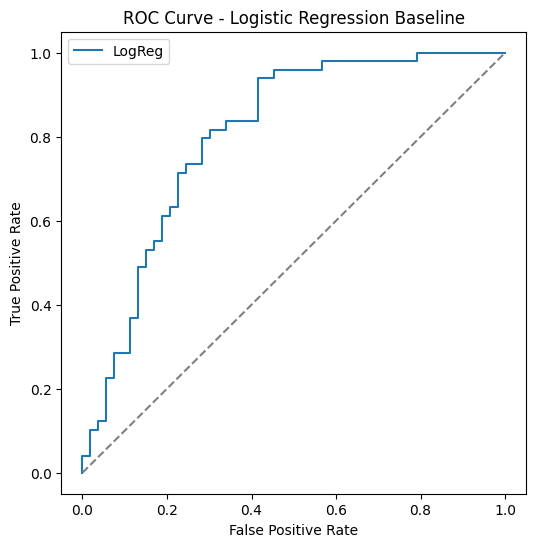

In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from PIL import Image
import os

#Split

df_train = pd.read_csv("../data/splits/train.csv")
df_val   = pd.read_csv("../data/splits/val.csv")
df_test  = pd.read_csv("../data/splits/test.csv")

# Majority Class Baseline

majority_class = df_train["label"].mode()[0]

y_val = df_val["label"].values
y_pred_majority = np.full(len(y_val), majority_class)

# Metrics
acc_majority = accuracy_score(y_val, y_pred_majority)
f1_majority  = f1_score(y_val, y_pred_majority, pos_label=1)

print("=== Majority Baseline ===")
print(f"Majority class: {majority_class}")
print(f"Accuracy: {acc_majority:.3f}")
print(f"F1 (potholes): {f1_majority:.3f}")
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_majority))

# Logistic Regression Baseline

def load_image(path, size=(64,64)):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    return np.array(img).flatten() / 255.0

X_train = np.array([load_image(p) for p in df_train["path"]])
y_train = df_train["label"].values

X_val = np.array([load_image(p) for p in df_val["path"]])
y_val  = df_val["label"].values

model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train, y_train)

# Predict
y_pred_logreg = model.predict(X_val)
y_prob_logreg = model.predict_proba(X_val)[:,1]

# Metrics
acc_logreg = accuracy_score(y_val, y_pred_logreg)
f1_logreg  = f1_score(y_val, y_pred_logreg, pos_label=1)
roc_auc    = roc_auc_score(y_val, y_prob_logreg)

print("\n=== Logistic Regression Baseline ===")
print(f"Accuracy: {acc_logreg:.3f}")
print(f"F1 (potholes): {f1_logreg:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_logreg))

# ROC Curve Visualization
fpr, tpr, _ = roc_curve(y_val, y_prob_logreg)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="LogReg")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression Baseline")
plt.legend()
plt.show()

In [14]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score


X_train = np.array([load_image(p) for p in df_train["path"]])
y_train = df_train["label"].values

X_val = np.array([load_image(p) for p in df_val["path"]])
y_val = df_val["label"].values


model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

model_xgb.fit(X_train, y_train)


y_pred_xgb = model_xgb.predict(X_val)
y_prob_xgb = model_xgb.predict_proba(X_val)[:,1]


acc_xgb = accuracy_score(y_val, y_pred_xgb)
f1_xgb = f1_score(y_val, y_pred_xgb, pos_label=1)
roc_auc = roc_auc_score(y_val, y_prob_xgb)
cm = confusion_matrix(y_val, y_pred_xgb)

print("=== XGBoost Baseline ===")
print(f"Accuracy: {acc_xgb:.3f}")
print(f"F1 (potholes): {f1_xgb:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print("Confusion Matrix:\n", cm)

D:\PycharmProjects\capstone2\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:18:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost Baseline ===
Accuracy: 0.775
F1 (potholes): 0.772
ROC-AUC: 0.866
Confusion Matrix:
 [[40 13]
 [10 39]]
